In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from labellines import labelLines

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='08-hyper-variation-with-fixed-epochs__batch_size_variation'

# Beamer 16:9
WIDTH=455.24408

#WIDTH=441.01775
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT='png'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

N_BOOTSTRAP_SAMPLES=100

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_data(data):
    records = []
    for experiment_details in data:
        # Extracting values from the JSON structure
        seed = subset_size = experiment_details['configuration']['seed']
        subset_size = experiment_details['configuration']['subset_size']
        batch_size = experiment_details['hyperparameters']['batch_size']
        
        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 5000 if subset_size == 0.1 else 50000
            batch_size = full_batch_size
            
        learning_rate = experiment_details['best_params']['learning_rate']
        max_grad_norm = experiment_details['best_params']['max_grad_norm']
        epochs = experiment_details['hyperparameters']['epochs']

        record = {
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'batch_size': batch_size,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'max_grad_norm': max_grad_norm,
            'epochs': epochs,
            'seed': seed,
        }
        records.append(record)

    return pd.DataFrame(records)

In [6]:
def bootstrap_confidence_interval(group, field, n_iterations=N_BOOTSTRAP_SAMPLES, ci=95):
    bootstrapped_means = []
    for _ in range(n_iterations):
        # Resample with replacement and calculate mean
        sample = group.sample(frac=1, replace=True)
        bootstrapped_means.append(sample[field].mean())

    # Calculating the confidence interval
    lower_bound = np.percentile(bootstrapped_means, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrapped_means, 100 - (100 - ci) / 2)

    return lower_bound, upper_bound

# Accuracy trends

In [7]:
def plot_accuracy_trends(prepared_data, output_dir=None):
    # Sort the data
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size', 'epochs'], inplace=True)
    
    # Group by model, dataset, subset size, and now epochs
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epochs'])

    for (model, dataset, subset, epochs), group in groups:
        fig, ax = get_figure((1, 1))
        model_name = MODEL_NAME_MAP.get(model, model)

        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            eps_data = eps_data.sort_values(by='batch_size')
            
            # Calculate confidence intervals for each batch size
            ci_lower = []
            ci_upper = []
            mean_accuracy = []
            batch_sizes = []
            for batch_size, batch_group in eps_data.groupby('batch_size'):
                lower, upper = bootstrap_confidence_interval(batch_group, 'accuracy')
                ci_lower.append(lower)
                ci_upper.append(upper)
                mean_accuracy.append(batch_group['accuracy'].mean())
                batch_sizes.append(batch_size)

            # Plotting the mean accuracy with error bars or shaded region
            ax.plot(batch_sizes, mean_accuracy, label=f'$\epsilon={epsilon}$', marker='o')
            ax.fill_between(batch_sizes, ci_lower, ci_upper, alpha=0.2)

        ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, {epochs} Epochs)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1])
        ax.set_xscale('log')

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)

        ax.legend()
        ax.grid(True)

        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)  # Ensure you have labelLines function defined or imported

        # Saving the plot if output_dir is specified
        if output_dir:
            filename = f'batch_size_variation_accuracy_trends_{model_name}_{dataset}_subset{int(subset*100)}_epochs{epochs}.{IMG_FORMAT}'
            plt.savefig(os.path.join(output_dir, filename))
        
        plt.show()


In [8]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

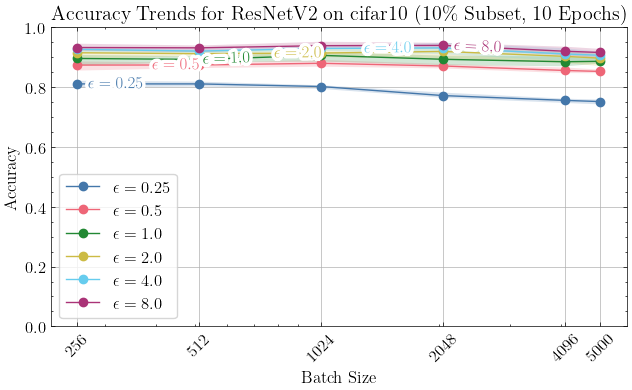

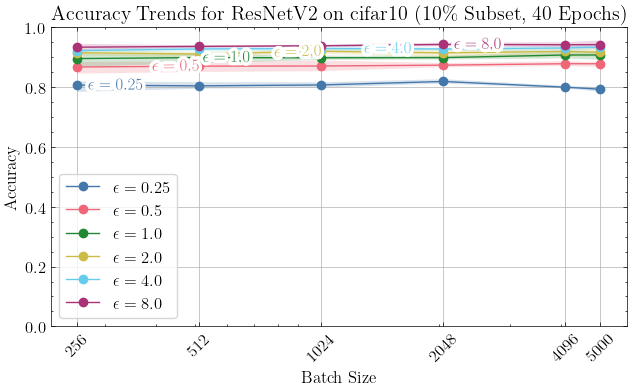

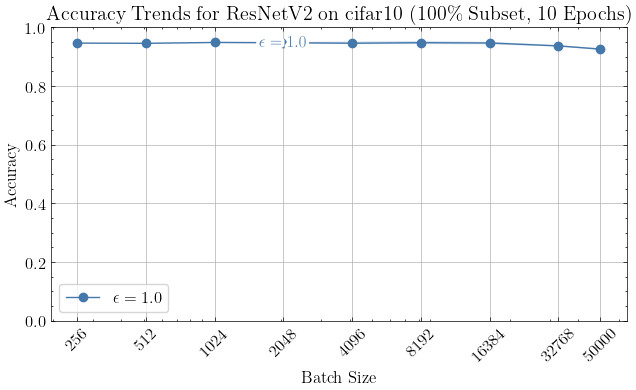

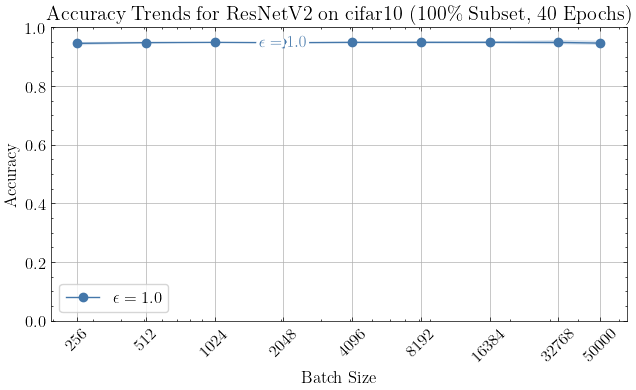

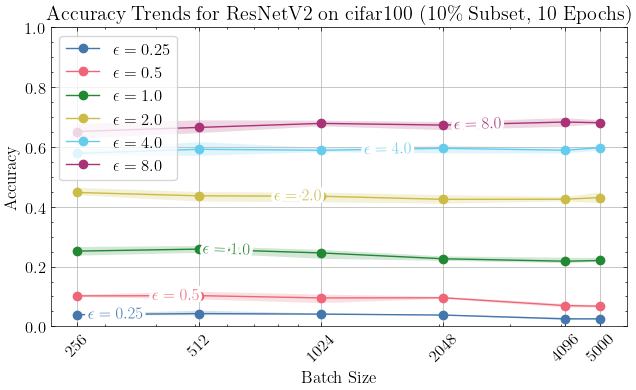

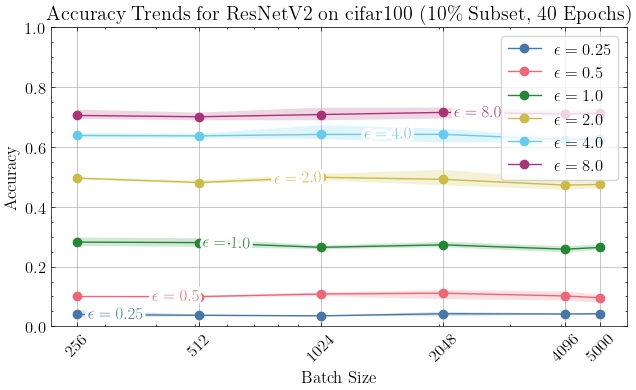

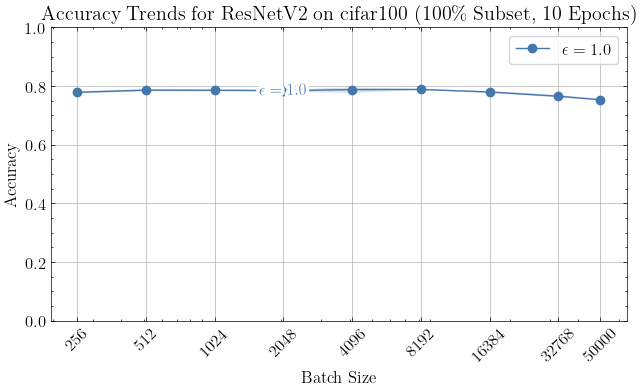

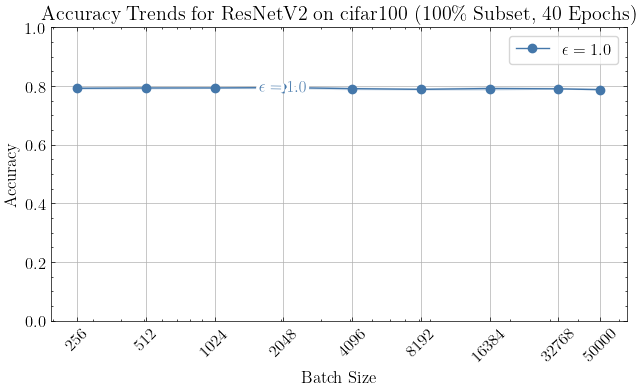

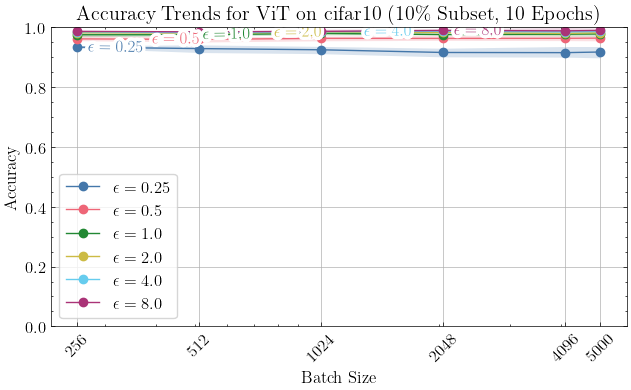

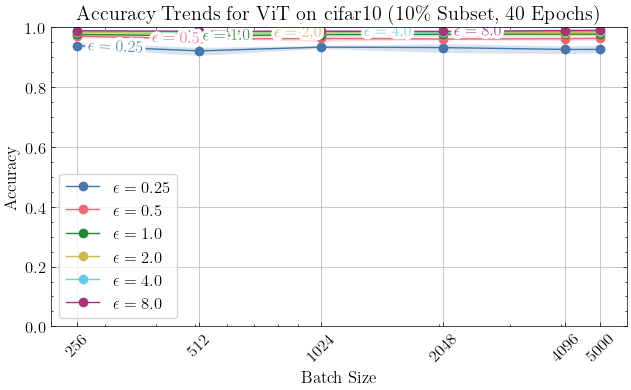

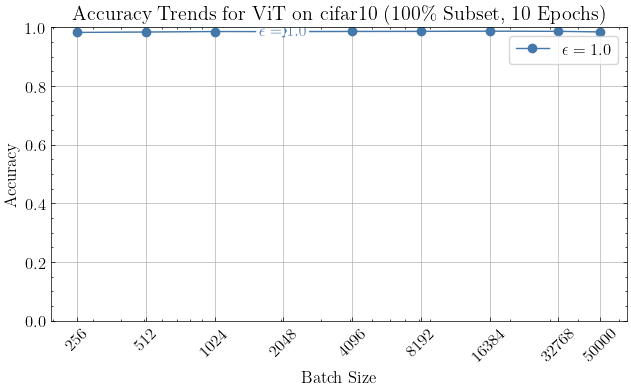

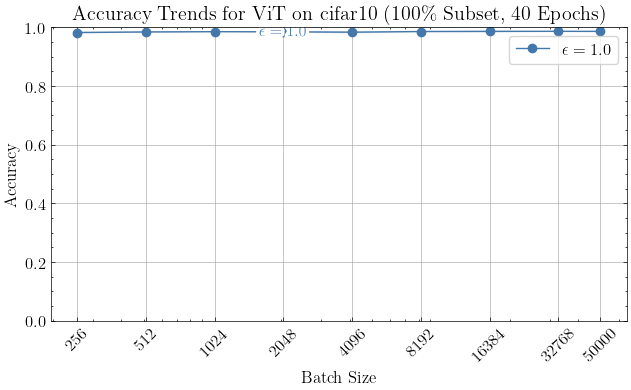

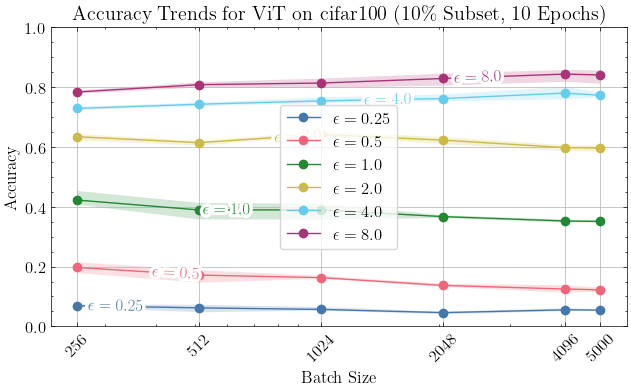

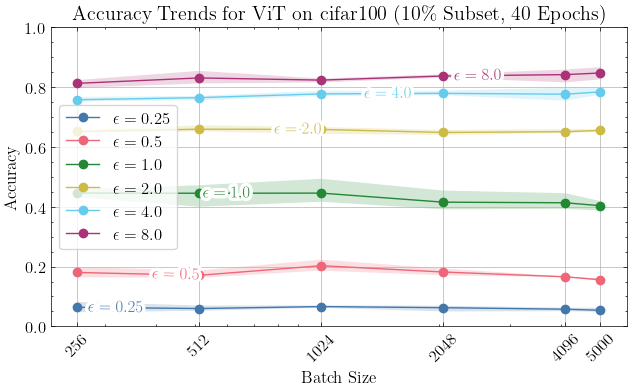

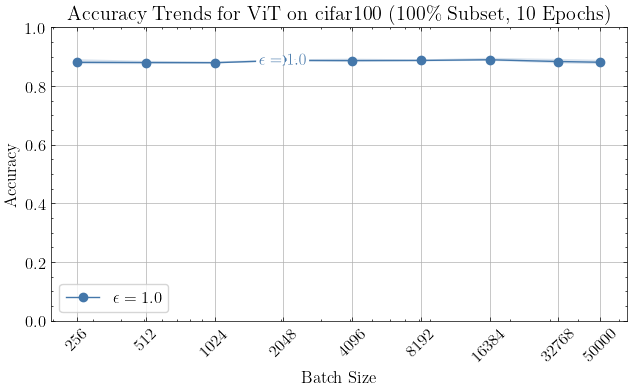

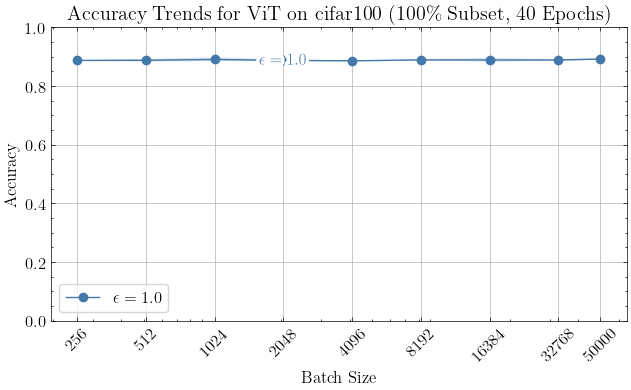

In [10]:
plot()

# Accuracy trends 10 vs 40 epochs

In [47]:
def plot_accuracy_trends_combined(prepared_data, output_dir=None):
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size'], inplace=True)    
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size'])

    for (model, dataset, subset), group in groups:
        fig, ax = get_figure((1, 1))
        model_name = MODEL_NAME_MAP.get(model, model)

        for epsilon, eps_data in group.groupby('epsilon'):
            color = next(ax._get_lines.prop_cycler)['color']

            # Separate plotting for 10 and 40 epochs
            for epochs in group['epochs'].unique():
                # Filter the group for the current epoch
                epoch_group = eps_data[eps_data['epochs'] == epochs]
                epoch_group = epoch_group.sort_values(by='batch_size')

                ci_lower = []
                ci_upper = []
                mean_accuracy = []
                batch_sizes = []
                for batch_size, batch_group in epoch_group.groupby('batch_size'):
                    lower, upper = bootstrap_confidence_interval(batch_group, 'accuracy')
                    ci_lower.append(lower)
                    ci_upper.append(upper)
                    mean_accuracy.append(batch_group['accuracy'].mean())
                    batch_sizes.append(batch_size)

                line_style = '-' if epochs == 40 else '--'
                ax.plot(batch_sizes, mean_accuracy, label=f'$\epsilon={epsilon}$, Epoch={epochs}', linestyle=line_style, marker='o', color=color)
                ax.fill_between(batch_sizes, ci_lower, ci_upper, alpha=0.2, color=color)

        ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1])
        ax.set_xscale('log')

        unique_batch_sizes = np.unique(eps_data['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)

        #ax.legend()
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
        ax.grid(True)

        # Saving the plot if output_dir is specified
        if output_dir:
            filename = f'combined_batch_size_variation_accuracy_trends_{model_name}_{dataset}_subset{int(subset*100)}.pdf'
            plt.savefig(os.path.join(output_dir, filename))
        
        plt.show()


In [48]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends_combined(processed_data, output_dir=OUTPUT_DIR)

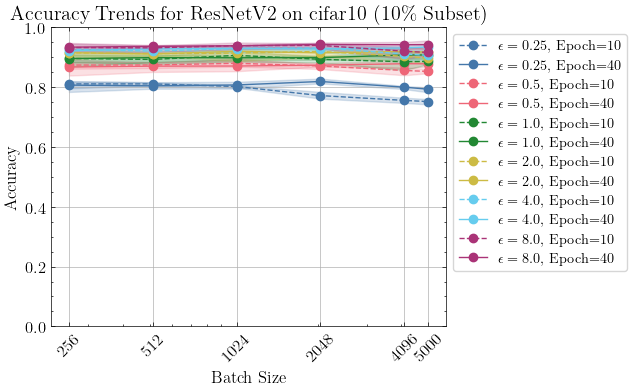

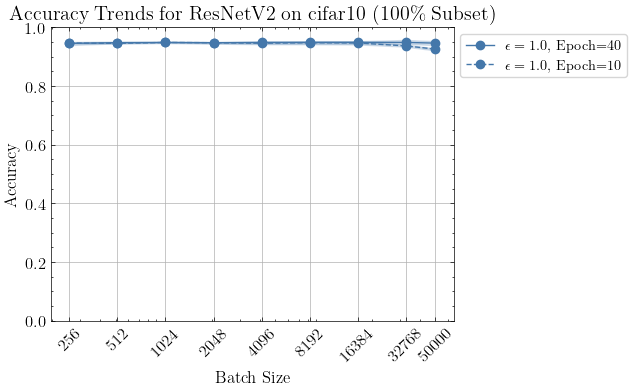

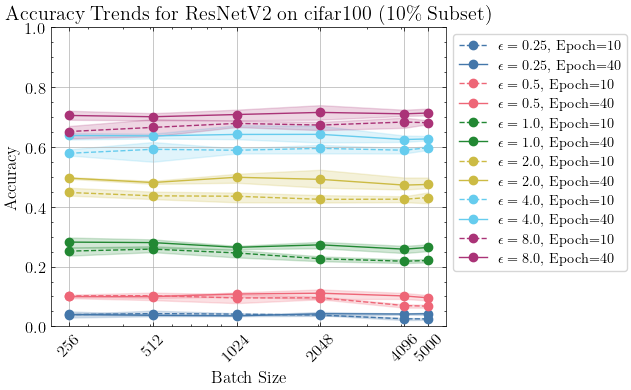

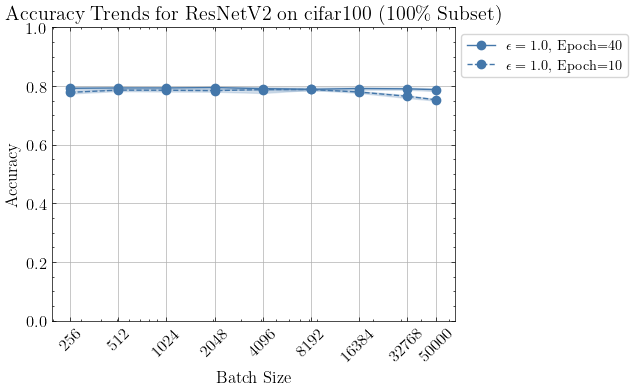

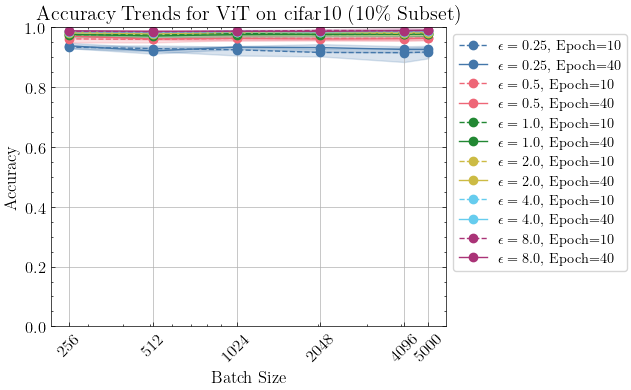

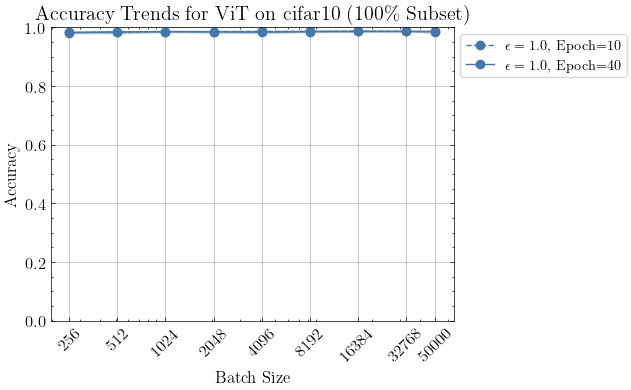

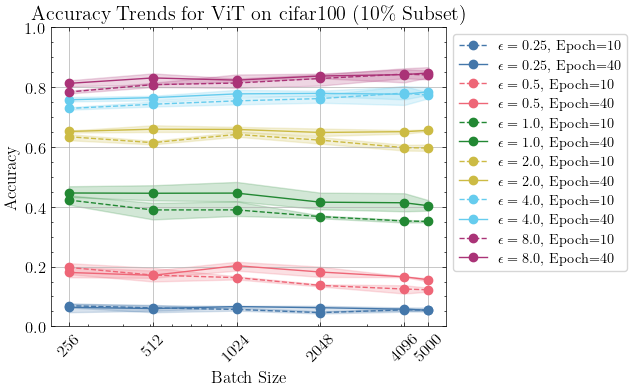

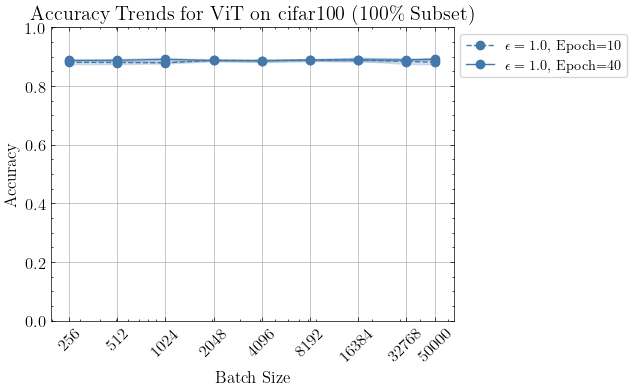

In [49]:
plot()

# Batch size vs Learning rate

In [11]:
def plot_learning_rate_trends(prepared_data, output_dir=None):
    # Sort the data including 'epochs'
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size', 'epochs'], inplace=True)
    
    # Group by model, dataset, subset size, and epochs
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epochs'])

    for (model, dataset, subset, epochs), group in groups:
        fig, ax = get_figure((1, 1))
        model_name = MODEL_NAME_MAP.get(model, model)

        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            eps_data = eps_data.sort_values(by='batch_size')
            
            # Calculate confidence intervals for each batch size
            ci_lower = []
            ci_upper = []
            mean_learning_rate = []
            batch_sizes = []
            for batch_size, batch_group in eps_data.groupby('batch_size'):
                lower, upper = bootstrap_confidence_interval(batch_group, 'learning_rate')
                ci_lower.append(lower)
                ci_upper.append(upper)
                mean_learning_rate.append(batch_group['learning_rate'].mean())
                batch_sizes.append(batch_size)

            # Plot with error bars or shaded region
            ax.plot(batch_sizes, mean_learning_rate, label=f'$\epsilon={epsilon}$', marker='o')
            ax.fill_between(batch_sizes, ci_lower, ci_upper, alpha=0.2)
        
        ax.set_title(f'Log-Log Learning Rate Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, {epochs} Epochs)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Learning Rate')
        ax.set_xscale('log')
        ax.set_yscale('log')

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)
        ax.legend()
        ax.grid(True)

        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)  # Assuming labelLines function is available

        # Save plot if output_dir is provided
        if output_dir:
            filename = f'batch_size_variation_learning_rate_trends_{model_name}_{dataset}_subset{int(subset*100)}_epochs{epochs}.{IMG_FORMAT}'
            plt.savefig(os.path.join(output_dir, filename))
        
        plt.show()


In [12]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_learning_rate_trends(processed_data, output_dir=OUTPUT_DIR)

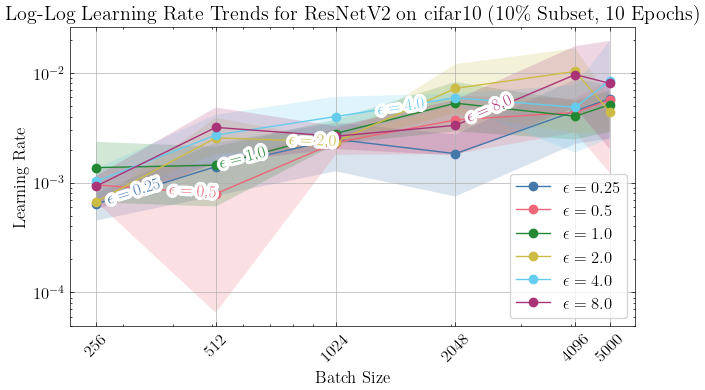

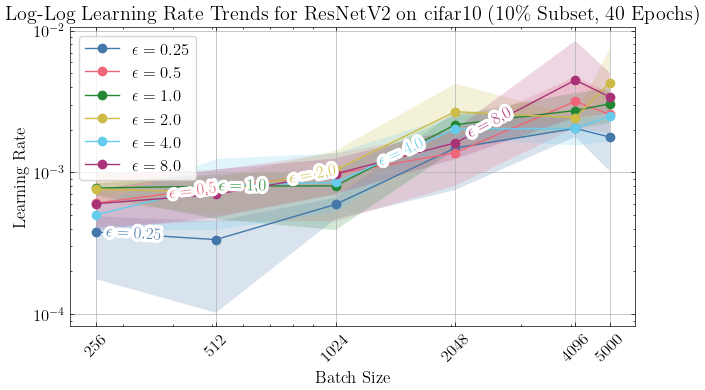

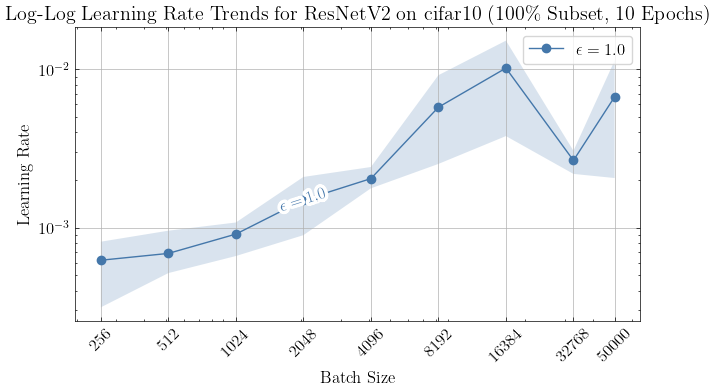

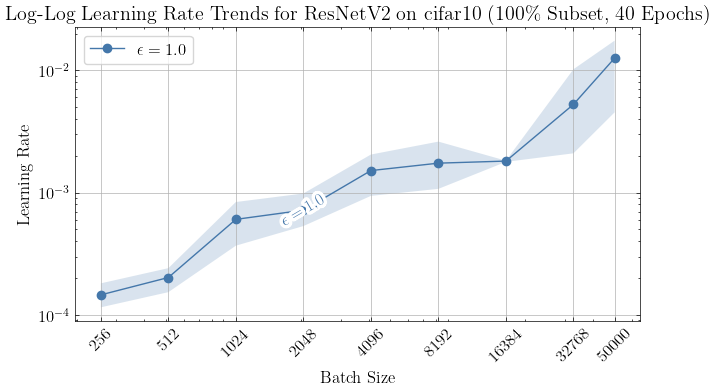

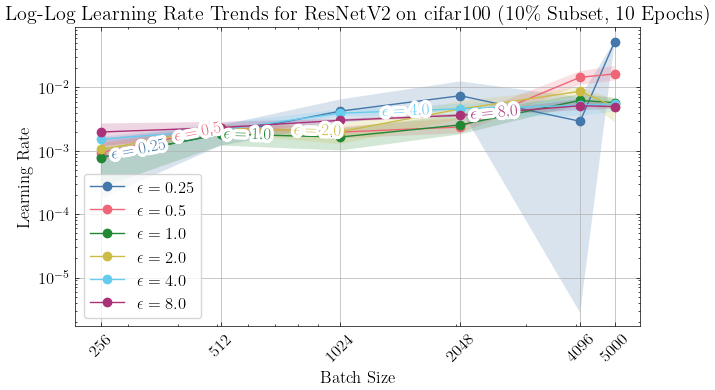

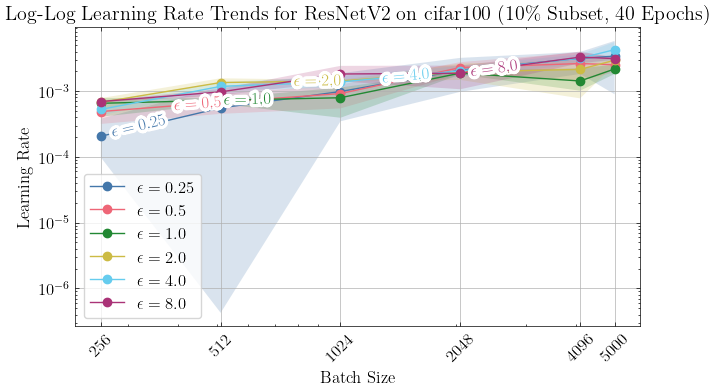

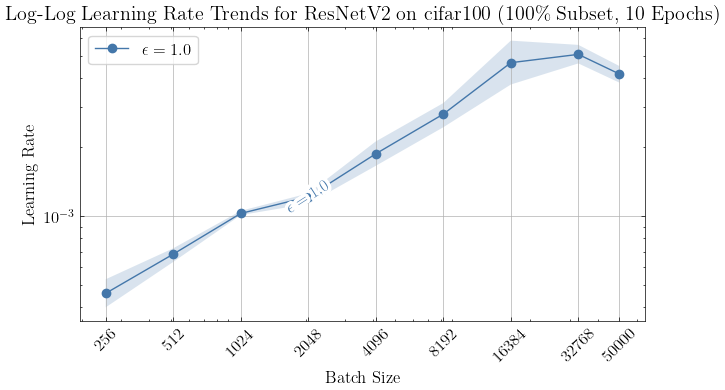

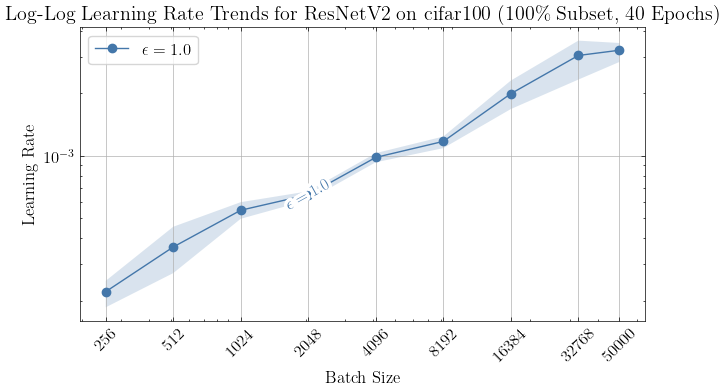

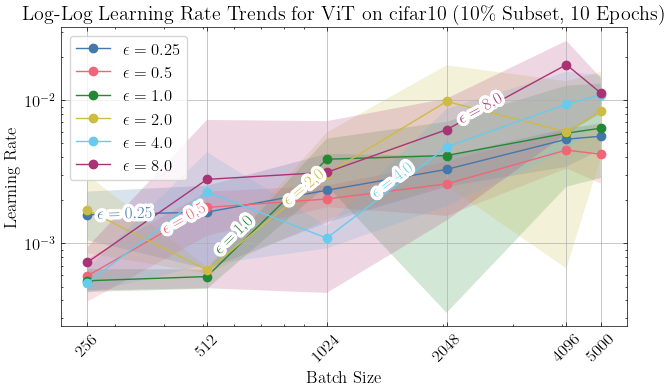

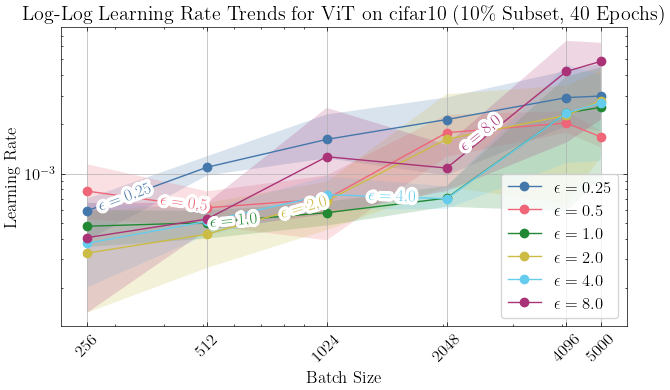

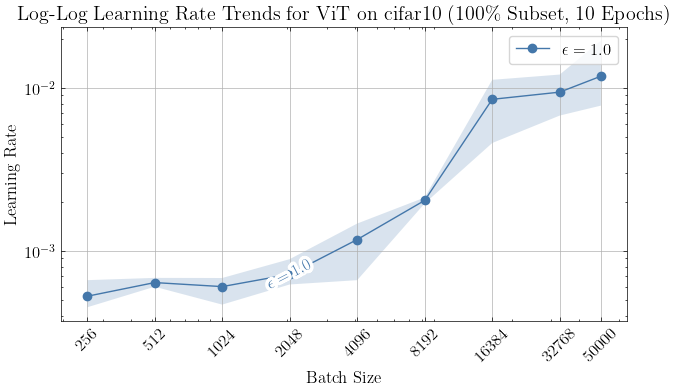

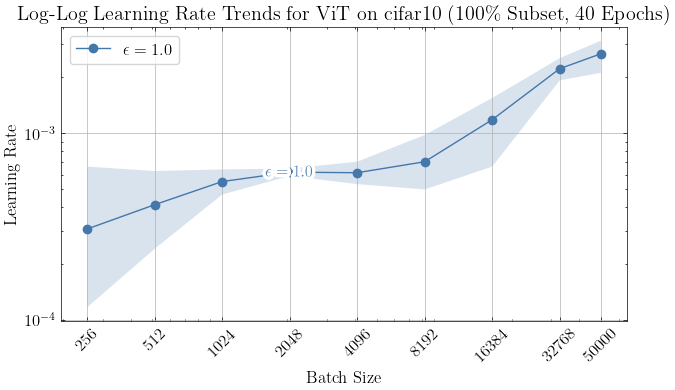

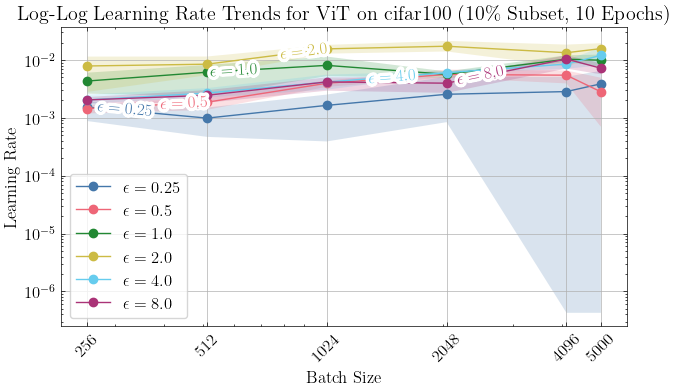

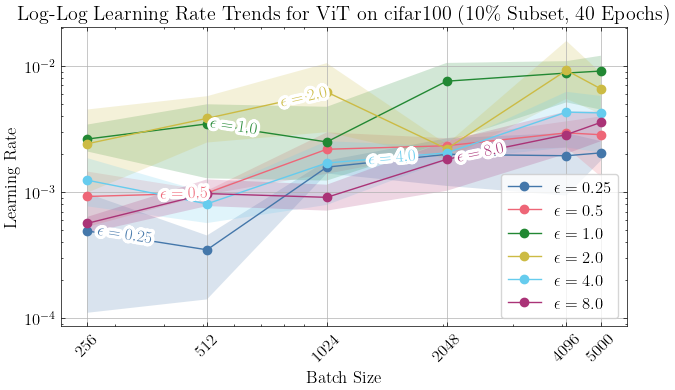

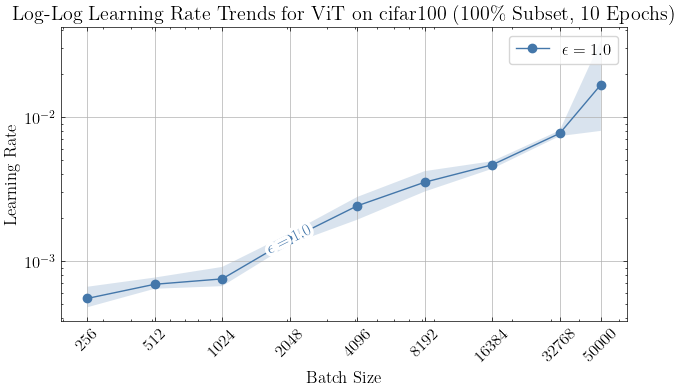

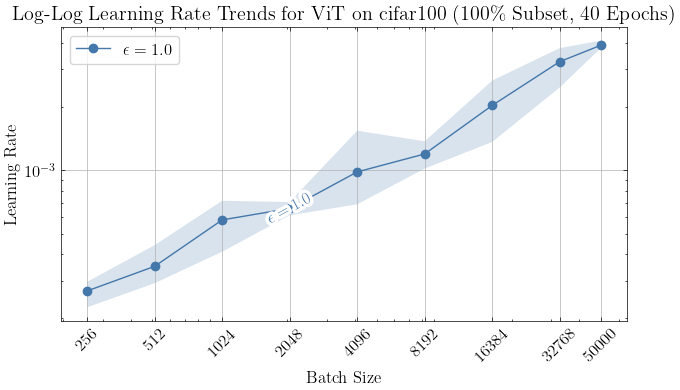

In [13]:
plot()

# Batch size vs Maximum gradient norm

In [14]:
def plot_max_grad_norm_trends(prepared_data, output_dir=None):
    # Sorting the data including 'epochs'
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size', 'epochs'], inplace=True)
    
    # Grouping by model, dataset, subset size, and epochs
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epochs'])

    for (model, dataset, subset, epochs), group in groups:
        fig, ax = get_figure((1, 1))
        model_name = MODEL_NAME_MAP.get(model, model)

        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            eps_data = eps_data.sort_values(by='batch_size')
            
            # Calculating confidence intervals for each batch size
            ci_lower = []
            ci_upper = []
            mean_max_grad_norm = []
            batch_sizes = []
            for batch_size, batch_group in eps_data.groupby('batch_size'):
                lower, upper = bootstrap_confidence_interval(batch_group, 'max_grad_norm')
                ci_lower.append(lower)
                ci_upper.append(upper)
                mean_max_grad_norm.append(batch_group['max_grad_norm'].mean())
                batch_sizes.append(batch_size)

            # Plotting with error bars or shaded region
            ax.plot(batch_sizes, mean_max_grad_norm, label=f'$\epsilon={epsilon}$', marker='o')
            ax.fill_between(batch_sizes, ci_lower, ci_upper, alpha=0.2)
        
        ax.set_title(f'Maximum Gradient Norm Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, {epochs} Epochs)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Maximum Gradient Norm')
        ax.set_xscale('log')  # Use log scale for batch size
        ax.set_ylim([0, 11])

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)
        ax.legend()
        ax.grid(True)

        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)  # Ensure you have labelLines function defined or imported

        # Saving the plot if output_dir is provided
        if output_dir:
            filename = f'batch_size_variation_max_grad_norm_trends_{model_name}_{dataset}_subset{int(subset*100)}_epochs{epochs}.{IMG_FORMAT}'
            plt.savefig(os.path.join(output_dir, filename))
        
        plt.show()


In [15]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_max_grad_norm_trends(processed_data, output_dir=OUTPUT_DIR)

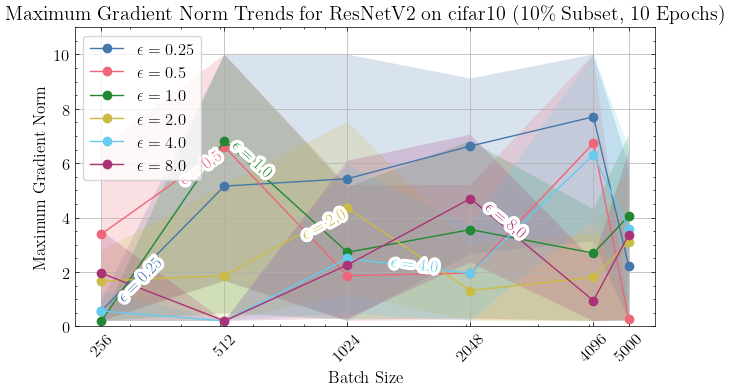

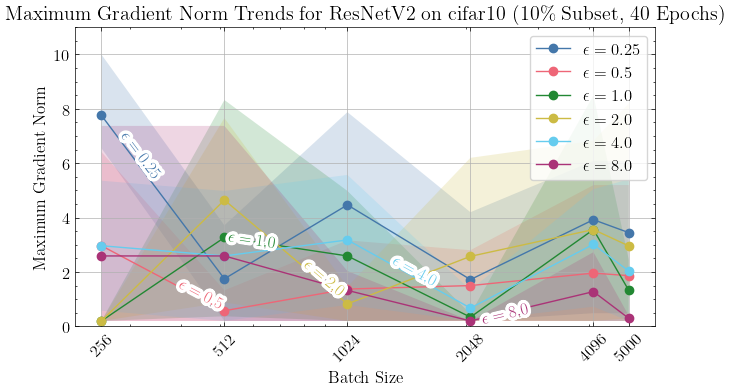

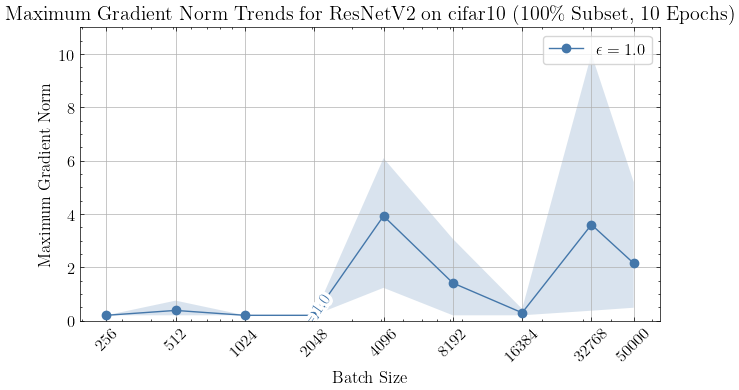

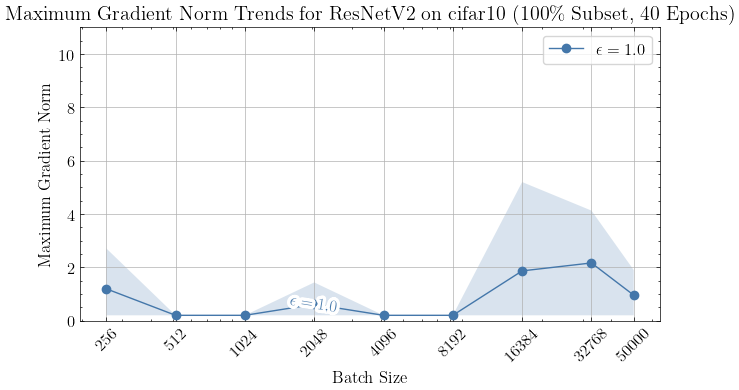

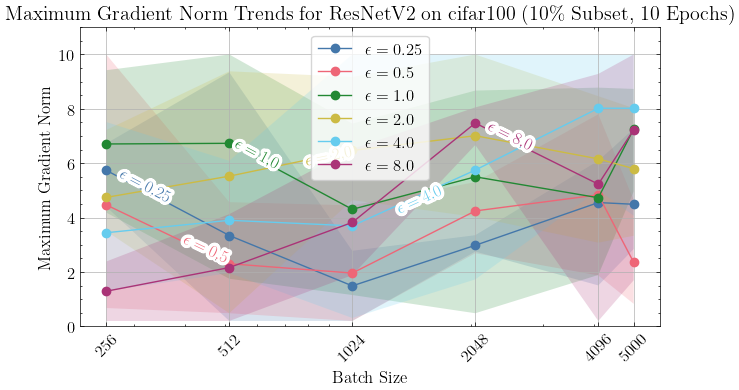

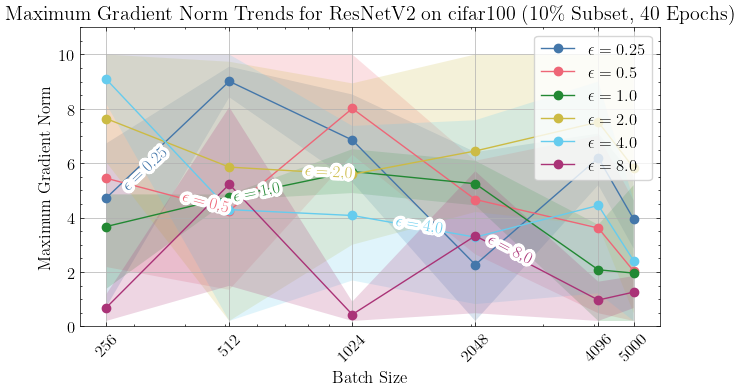

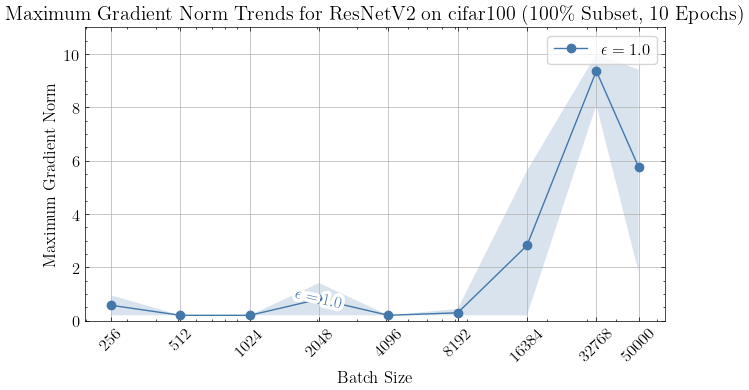

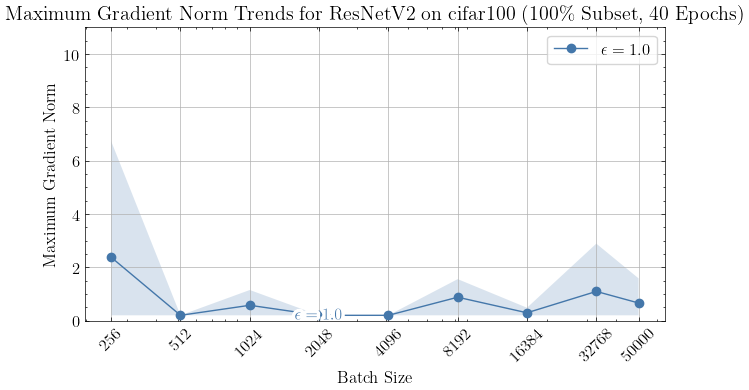

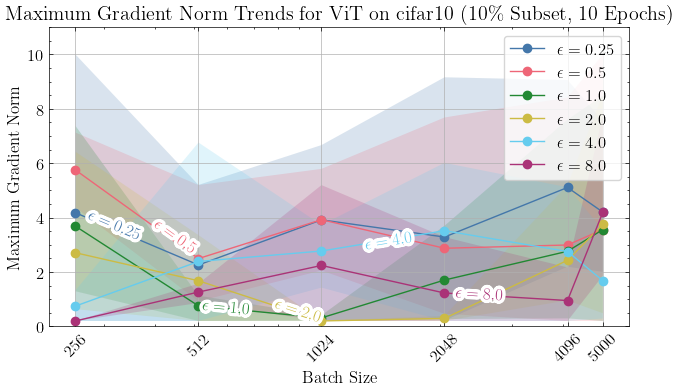

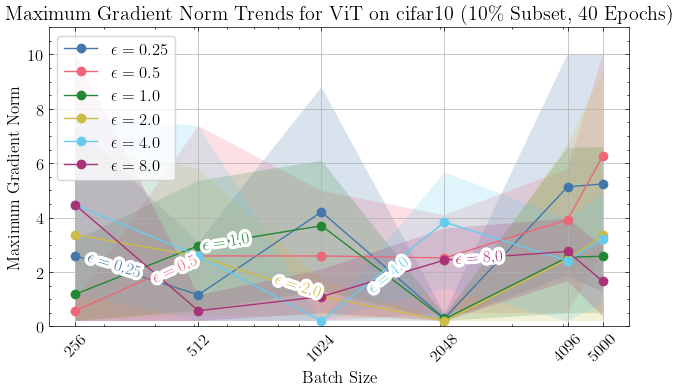

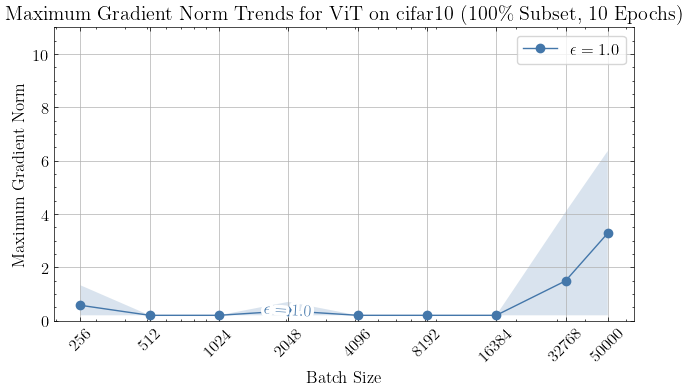

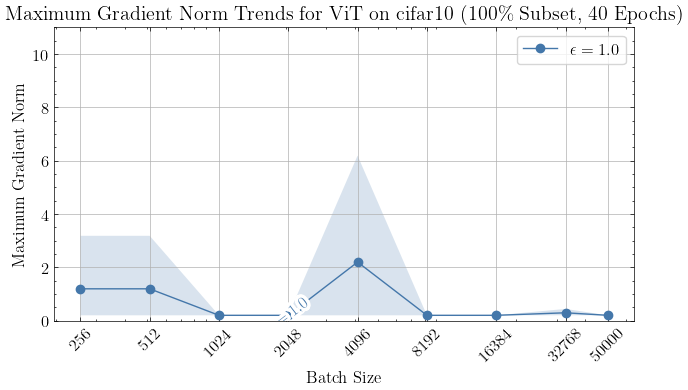

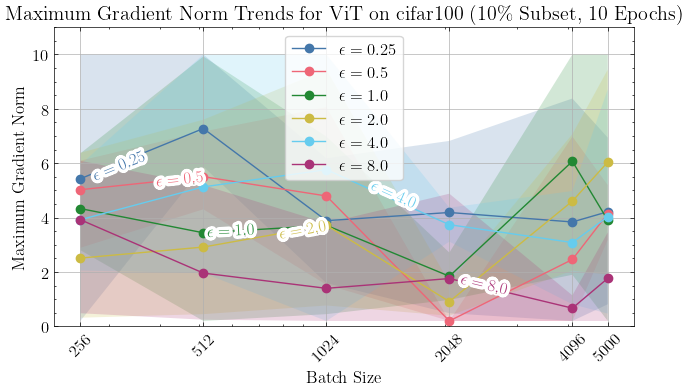

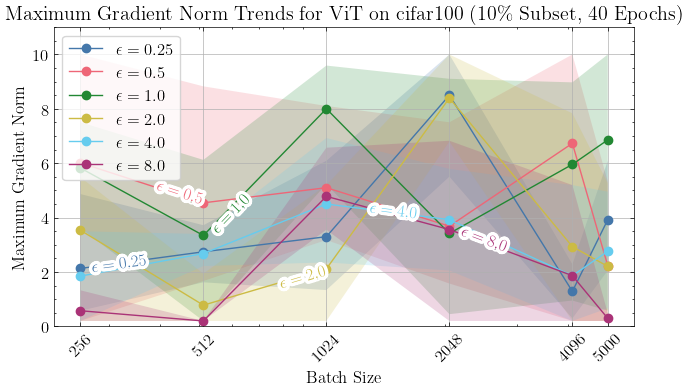

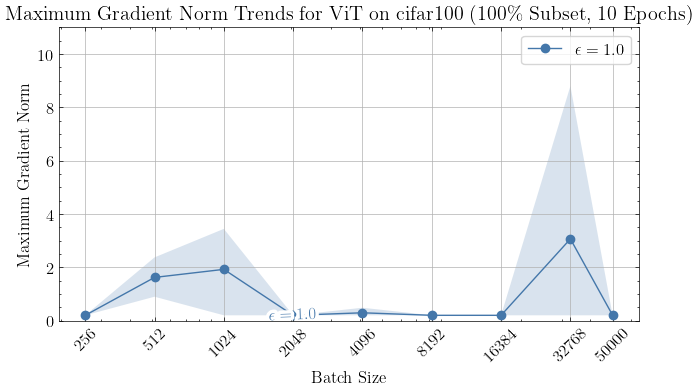

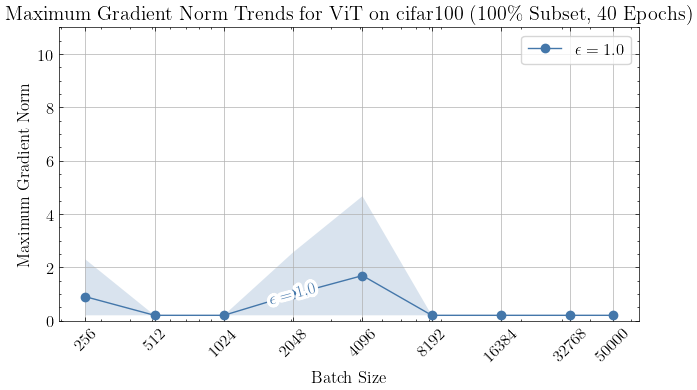

In [16]:
plot()